<a href="https://colab.research.google.com/github/Renad-Alzahrani-gif/house-prices-prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
upload=files.upload()

Saving train.csv to train (1).csv


In [3]:
import pandas as pd
read=pd.read_csv('train.csv')
read.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor


# 1. Data

y = read['SalePrice']

x = read.drop(['SalePrice'], axis=1)



# 2. Data Split

x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    random_state=0
)


# 3.  Identify Categorical and Numerical Columns
categorical_columns = [
    co for co in x_train.columns
    if x_train[co].dtype == 'object'
]

numerical_columns = [
    co for co in x_train.columns
    if x_train[co].dtype in ["int64", "float64"]
]



# 4. Preprocessing

num_handle = SimpleImputer(
    strategy="median"
)


Cat_handle = Pipeline(steps=[
    (
        "clean",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])


column = ColumnTransformer(transformers=[
    (
        "num",
        num_handle,
        numerical_columns
    ),
    (
        "cat",
        Cat_handle,
categorical_columns     )
])


# 5. XGBoost Model

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1,

)


# 6. Pipeline

myPipline = Pipeline(steps=[
    (
        "preprosess",
        column
    ),
    (
        "model",
        model
    )
])


myPipline.fit(x_train, y_train)

feature_names = myPipline.named_steps["preprosess"].get_feature_names_out()

importances = myPipline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
# 7. Cross Validation

scoring = -1 * cross_val_score(
    myPipline,
    x,
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)



# 8. Result

print("\nMean MAE:")
print(scoring.mean())
print(importance_df.head(20))



Mean MAE:
15117.04609375
                   Feature  Importance
4         num__OverallQual    0.193506
26         num__GarageCars    0.170648
243  cat__GarageFinish_Unf    0.062060
178       cat__BsmtQual_Ex    0.039757
223    cat__KitchenQual_TA    0.029166
16          num__GrLivArea    0.029054
166      cat__ExterQual_TA    0.022114
22       num__KitchenAbvGr    0.021186
19           num__FullBath    0.018007
213      cat__CentralAir_N    0.016780
40        cat__MSZoning_RL    0.013949
214      cat__CentralAir_Y    0.013287
41        cat__MSZoning_RM    0.011919
12        num__TotalBsmtSF    0.011785
6           num__YearBuilt    0.011590
24         num__Fireplaces    0.011412
192  cat__BsmtFinType1_GLQ    0.011083
195  cat__BsmtFinType1_Unf    0.010749
13           num__1stFlrSF    0.010191
9          num__BsmtFinSF1    0.009661


Validation MAE: 15335.232421875

Largest 10 Errors:
     Actual      Predicted          Error  Absolute Error
8    745000  438994.312500  306005.687500   306005.687500
259  160000  359769.125000 -199769.125000   199769.125000
73   392000  229752.937500  162247.062500   162247.062500
258  538000  416796.906250  121203.093750   121203.093750
216   82500  185510.906250 -103010.906250   103010.906250
215  129000  206008.906250  -77008.906250    77008.906250
288  555000  487501.593750   67498.406250    67498.406250
44   403000  337486.281250   65513.718750    65513.718750
276  164000  224780.484375  -60780.484375    60780.484375
34   372500  313667.531250   58832.468750    58832.468750
Validation R²: 0.8744663000106812


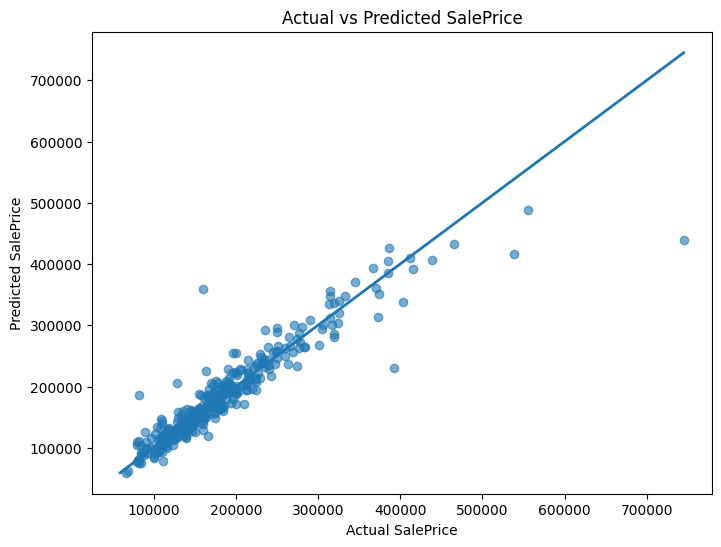

Percentage under predicted: 52.054794520547944 %


In [9]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error , r2_score

from xgboost import XGBRegressor



# 1. Data

y = read["SalePrice"]

x = read.drop(["SalePrice"], axis=1)



# 2. Data Split


x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    random_state=0
)



# 3. Identify Categorical and Numerical Columns


categorical_columns = [
    co for co in x_train.columns
    if x_train[co].dtype == "object"
]

numerical_columns = [
    co for co in x_train.columns
    if x_train[co].dtype in ["int64", "float64"]
]



# 4. Preprocessing


num_handle = SimpleImputer(
    strategy="median"
)


Cat_handle = Pipeline(steps=[
    (
        "clean",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])


column = ColumnTransformer(transformers=[
    (
        "num",
        num_handle,
        numerical_columns
    ),
    (
        "cat",
        Cat_handle,
        categorical_columns
    )
])



# 5. XGBoost

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)



# 6. Pipeline


myPipline = Pipeline(steps=[
    (
        "preprosess",
        column
    ),
    (
        "model",
        model
    )
])



# 7. Training

myPipline.fit(
    x_train,
    y_train
)



# 8. Prediction


predictions = myPipline.predict(
    x_valid
)



# 9. MAE


mae = mean_absolute_error(
    y_valid,
    predictions
)

r2 = r2_score(
    y_valid,
    predictions
)



results = pd.DataFrame({
    "Actual": y_valid.reset_index(drop=True),
    "Predicted": predictions
})

results["Error"] = (
    results["Actual"] - results["Predicted"]
)

results["Absolute Error"] = abs(
    results["Error"]
)

results = results.sort_values(
    by="Absolute Error",
    ascending=False
)

print("Validation MAE:", mae)

print("\nLargest 10 Errors:")
print(results.head(10))


print("Validation R²:", r2)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_valid,
    predictions,
    alpha=0.6
)

min_value = min(y_valid.min(), predictions.min())
max_value = max(y_valid.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")

plt.show()

under_predictions = (predictions < y_valid).mean()

print("Percentage under predicted:",
      under_predictions * 100, "%")